In [1]:
from pathlib import Path
import time
from collections import deque

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
def calc_mu_sigma(k, e, vs):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)
    return mu, sigma

def is_out_of_range(y, x, N):
    return not ((0 <= x < N) and (0 <= y < N))

In [5]:
class Env:

    def __init__(self, file_path):
        with open(file_path, mode="r") as f:
            lines = f.readlines()
            N, M, ESP = lines[0].split()
            N, M, ESP = int(N), int(M), float(ESP)
            GRID = []
            lines = lines[1:]
            for _line in lines[:M]:
                _line = _line.split()
                ps = []
                for i in range(int(_line[0])):
                    ps.append((int(_line[2 * i + 1]), int(_line[2 * i + 2])))
                GRID.append(ps)
            lines = lines[2*M:]
            ANS_GRID = []
            for _line in lines[:N]:
                ANS_GRID.append(list(map(int, _line.split())))
        
        self.N = N
        self.M = M
        self.esp = ESP
        self.grids = GRID
        self.ans_grid = ANS_GRID

        self.total_size = sum(len(g) for g in self.grids)
        self._score = 0
        self.score = 10 ** 9

        cnt = 0
        for x in range(N):
            for y in range(N):
                if self.ans_grid[y][x] > 0:
                    cnt += 1
        self.ans_point_size = cnt
    
    def query1(self, coordinate):
        y, x = coordinate
        self._score += 1
        return self.ans_grid[y][x]

    def query2(self, coordinates):
        k = len(coordinates)
        vs = sum(self.ans_grid[y][x] for y, x in coordinates)
        mu, sigma = calc_mu_sigma(k, self.esp, vs)
        rng = np.random.default_rng()
        r = rng.normal(mu, sigma)
        self._score += 1 / np.sqrt(k)
        return max(0, round(r))

    def answer(self, coordinates):
        is_ok = self.total_size == sum(self.ans_grid[y][x] for y, x in coordinates)
        if is_ok:
            self.score = self._score
        else:
            self._score += 1
        return is_ok

In [6]:
class InformationVolumeSolver:
    
    """
        情報量を下げるように探索をする
    """

    def __init__(self, env: Env, N:int, M:int):
        self.env: Env = env
        self.N = N
        self.M = M

        self._total_size = 0
        self._ans = []
        self._grid_response = [[False for _ in range(N)] for _ in range(N)]

        self._init_infos()

    def solve(self):
        for _ in range(500):
            if self._total_size == self.env.total_size:
                return self.env.answer(self._ans)
            coordinate = self._calc_most_information_point()
            resp = self.env.query1(coordinate)
            if resp > 0:
                self._total_size += resp
                self._ans.append(coordinate)
            y, x = coordinate
            self._grid_response[y][x] = True
            self._update_prob_map(coordinate, resp)
        raise ValueError("Why?")

    def _init_infos(self):
        placements_grid_num_dict = {}
        placements_proba_dict = {}

        for m in range(self.env.M):
            placements_grid_set = [[set() for _ in range(self.N)] for _ in range(self.N)]
            placements_proba = np.zeros((self.N, self.N), dtype=np.float64)
            target_grids = self.env.grids[m]
            t = 0
            for x in range(self.N):
                for y in range(self.N):
                    tmp_grids = []
                    is_ok = True
                    for coordinate in target_grids:
                        ny, nx = coordinate[0] + y, coordinate[1] + x
                        if is_out_of_range(ny, nx, self.N):
                            is_ok = False
                            break
                        tmp_grids.append((ny, nx))
                    if not is_ok:
                        continue
                    for coordinate in tmp_grids:
                        ty, tx = coordinate
                        placements_grid_set[ty][tx].add((y, x))
                    placements_proba[y][x] = 1
                    t += 1
            placements_grid_num_dict[m] = placements_grid_set
            placements_proba_dict[m] = placements_proba / t

        self.placements_grid_num_dict = placements_grid_num_dict
        self.placements_proba_dict = placements_proba_dict

    def _calc_mean_infomation_value(self, probs):
        ret = 0
        for prob in probs:
            if prob > 0:
                ret -= prob * np.log2(prob)
        return ret / len(probs)
    
    def _calc_most_information_point(self):
        best_point = None
        best_score = -1
        for x in range(self.N):
            for y in range(self.N):
                if self._grid_response[y][x]:
                    continue
                probs = [self.placements_proba_dict[m][y][x] for m in range(self.M)]
                mean_infomation_value = self._calc_mean_infomation_value(probs)
                if best_score < mean_infomation_value:
                    best_score = mean_infomation_value
                    best_point = y, x
        return best_point

    def _update_prob_map(self, update_coordinate, resp_val):
        for m in range(self.M):
            total_num = 0
            total_prob = 0
            for x in range(self.N):
                for y in range(self.N):
                    if update_coordinate in self.placements_grid_num_dict[m][y][x]:
                        total_num += 1
                        total_prob += self.placements_proba_dict[m][y][x]
            not_num = self.N ** 2 - total_num
            not_prob = 1- total_prob
            if total_num == 0 or total_prob == 0:
                continue
            if resp_val == 0:
                for x in range(self.N):
                    for y in range(self.N):
                        if update_coordinate in self.placements_grid_num_dict[m][y][x]:
                            self.placements_proba_dict[m][y][x] = 0
                        else:
                            self.placements_proba_dict[m][y][x] *= 1/not_prob
                continue
            
            p1 = (self.N**2) / (self.M * total_num)
            p2 = (self.N**2 * (self.M-1)) / self.M*not_num
            std_fact = 1 / (total_prob * p1 + not_prob * p2)
            p1 *= std_fact
            p2 *= std_fact
            
            for x in range(self.N):
                for y in range(self.N):
                    if update_coordinate in self.placements_grid_num_dict[m][y][x]:
                        self.placements_proba_dict[m][y][x] = self.placements_proba_dict[m][y][x] * p1
                    else:
                        self.placements_proba_dict[m][y][x] = self.placements_proba_dict[m][y][x] * p2

In [7]:
import random

scores = []
n_size = []
ans_points = []

random.seed(0)
for test_num in range(100):
    env = Env(file_path = Path(f"./in/{test_num:0>4}.txt"))
    solver = InformationVolumeSolver(env=env, N=env.N, M=env.M)
    solver.solve()
    scores.append(env.score)
    n_size.append(env.N**2)
    ans_points.append(env.ans_point_size)

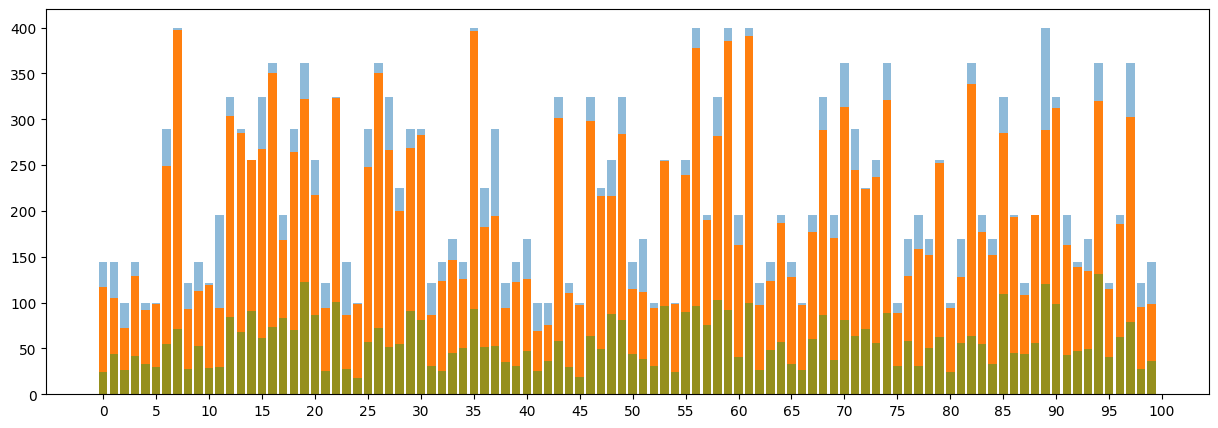

195.12


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.bar(list(range(len(n_size))), n_size, alpha=0.5)
plt.bar(list(range(len(scores))), scores)
plt.bar(list(range(len(ans_points))), ans_points, alpha=0.5)

plt.xticks(range(0, len(scores)+1, 5))
plt.show()

print(sum(scores) / len(scores))

In [9]:
# ok_start_points_all = dict()
# for m in range(env.M):
#     target_grids = env.grids[m]
#     ok_start_points = []
#     for y in range(env.N):
#         for x in range(env.N):
#             is_ok = True
#             for coordinate in target_grids:
#                 ny, nx = y + coordinate[0], x + coordinate[1]
#                 if is_out_of_range(ny, nx, env.N):
#                     is_ok = False
#                     break
#             if is_ok:
#                 ok_start_points.append((y, x))
#     ok_start_points_all[m] = ok_start_points

In [10]:
# import itertools

# all_grids = []
# all_combs = list(itertools.product(*[ok_start_points_all[m] for m in range(env.M)]))
# for comb in all_combs:
#     now_grid = [[0 for _ in range(env.N)] for _ in range(env.N)]
#     for m in range(env.M):
#         s_point = comb[m]
#         for y, x in env.grids[m]:
#             ny, nx = y + s_point[0], x + s_point[1]
#             now_grid[ny][nx] += 1
#     all_grids.append(now_grid)

In [11]:
# def plot_grid(grid):
#     x_list = []
#     y_list = []
#     for coordinate in grid:
#         y, x = coordinate
#         x_list.append(x)
#         y_list.append(y)
#     x_max = max(x_list)
#     y_max = max(y_list)
#     disp_grid = [["." for _ in range(x_max+1)] for _ in range(y_max+1)]
#     for coordinate in grid:
#         ty, tx = coordinate
#         disp_grid[ty][tx] = "#"
#     for line in disp_grid:
#         print("".join(line))

In [12]:
# import random
# for i in range(100):
#     t = random.randint(0, env.N**2 -1)
#     # y, x = solver.calc_most_infomation_point()
#     # print(y, x)
#     y, x = t % env.N, t // env.N 
#     resp = env.query1((y, x))
#     solver._update_prob_map((y, x), resp)
#     if i % 10 == 0:
#         print(f"----- {i} -----")
#         plt.figure(figsize=(3,3))
#         plt.imshow(solver.placements_proba_dict[0])
#         plt.show()